# $O(n)$

## 1. Import các thư viện

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
from utils import plot_execution_times, measure_algorithm_time

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Cài đặt thuật toán có độ phức tạp $O(n)$

Nhóm thuật toán **tuyến tính** thường không dựa vào so sánh trực tiếp từng cặp phần tử, mà khai thác **đặc trưng miền giá trị của khóa** để sắp xếp nhanh hơn. Khi các giả định đầu vào phù hợp (dữ liệu nguyên, miền giá trị không quá lớn hoặc số chữ số cố định), thời gian thực thi có thể tiến gần **$O(n)$**.

Trong nhóm này, notebook lựa chọn hai thuật toán đại diện:

- **Counting Sort**: đếm tần suất xuất hiện của từng khóa rồi tái tạo mảng kết quả.
- **Radix Sort (LSD, base 10)**: sắp xếp theo từng chữ số bằng một bước đếm ổn định.

Lý do chọn bộ đôi này:

- Cả hai đều thể hiện rõ tư duy sắp xếp **không dựa trên so sánh**.
- **Counting Sort** nhạy với độ rộng miền khóa `k` (độ phức tạp `O(n + k)`).
- **Radix Sort** có độ phức tạp `O(d * (n + b))`; với `d` và `b` nhỏ, có thể xem gần tuyến tính theo `n`.

Với bộ dữ liệu bài tập (số nguyên không âm), hai thuật toán này phù hợp để quan sát hành vi của nhóm `O(n)` trên 4 kiểu phân bố dữ liệu.

### 2.1 Counting Sort

In [16]:
def counting_sort(arr):
    if len(arr) <= 1:
        return arr

    max_value = int(np.max(arr))
    count = np.zeros(max_value + 1, dtype=np.int64)

    for value in arr:
        count[int(value)] += 1

    index = 0
    for value, freq in enumerate(count):
        if freq > 0:
            arr[index:index + freq] = value
            index += freq

    return arr

### 2.2 Radix Sort (LSD, base 10)

In [17]:
def counting_sort_by_digit(arr, exp):
    n = len(arr)
    output = np.zeros(n, dtype=arr.dtype)
    count = np.zeros(10, dtype=np.int64)

    for i in range(n):
        digit = (int(arr[i]) // exp) % 10
        count[digit] += 1

    for i in range(1, 10):
        count[i] += count[i - 1]

    for i in range(n - 1, -1, -1):
        digit = (int(arr[i]) // exp) % 10
        output[count[digit] - 1] = arr[i]
        count[digit] -= 1

    arr[:] = output


def radix_sort(arr):
    if len(arr) <= 1:
        return arr

    max_value = int(np.max(arr))
    exp = 1

    while max_value // exp > 0:
        counting_sort_by_digit(arr, exp)
        exp *= 10

    return arr

## 3. Đọc dữ liệu từ file npz

In [13]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']
base_path = '../data/' 

# Từ điển lưu trữ dữ liệu đã đọc: cấu trúc loaded_data['tên_dataset']['kích_thước']
loaded_data = {data_type: {} for data_type in datasets}

print("Đang tải dữ liệu lên bộ nhớ...")
for data_type in datasets:
    for size in sizes:
        folder_name = f'n_{size}'
        file_name = f'{data_type}_n{size}.npz'
        file_path = os.path.join(base_path, folder_name, file_name)
        
        try:
            npz_file = np.load(file_path)
            keys = npz_file.files
            # Lưu mảng dữ liệu vào từ điển
            loaded_data[data_type][size] = npz_file[keys[0]]
        except Exception as e:
            print(f"Lỗi với file {file_path}: {e}")
            loaded_data[data_type][size] = None

print("Đã tải xong toàn bộ dữ liệu!")

Đang tải dữ liệu lên bộ nhớ...
Đã tải xong toàn bộ dữ liệu!


## 4. Đo thời gian

### 4.1 Đo với thuật toán Counting Sort

In [22]:
print("Đang đo Counting Sort")
results_counting_sort = measure_algorithm_time(counting_sort, loaded_data, datasets, sizes)
results_counting_sort

Đang đo Selection Sort


### 4.2 Đo với thuật toán Radix Sort

In [19]:
print("Đang đo Radix Sort")
results_radix_sort = measure_algorithm_time(radix_sort, loaded_data, datasets, sizes)
results_radix_sort

Đang đo Insertion Sort


## 5. Biểu đồ trực quan

### 5.1 Counting Sort

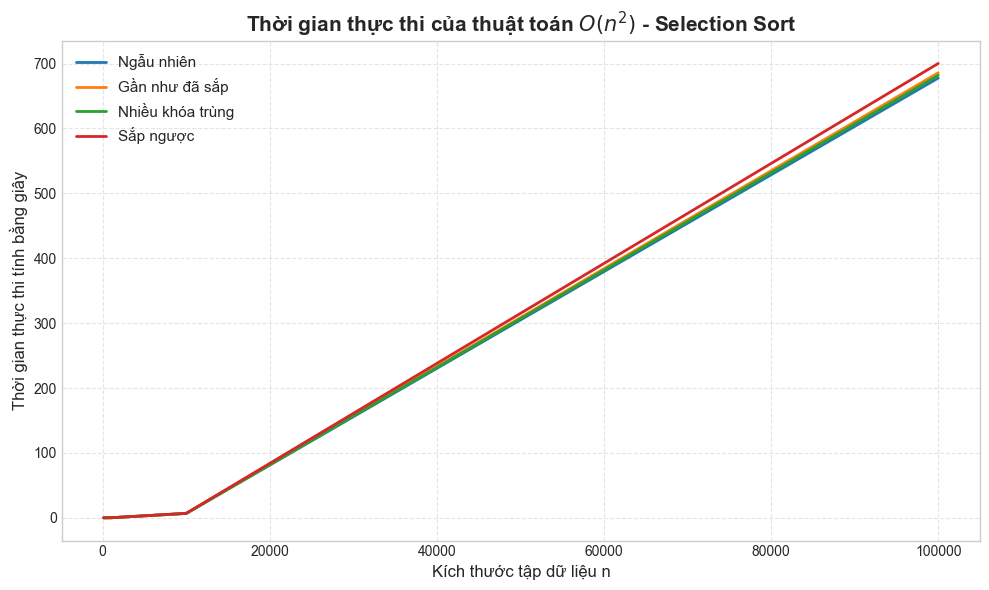

In [ ]:
plot_execution_times(
    results_dict=results_counting_sort, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="$O(n)$ - Counting Sort"
)


### 5.2 Radix Sort

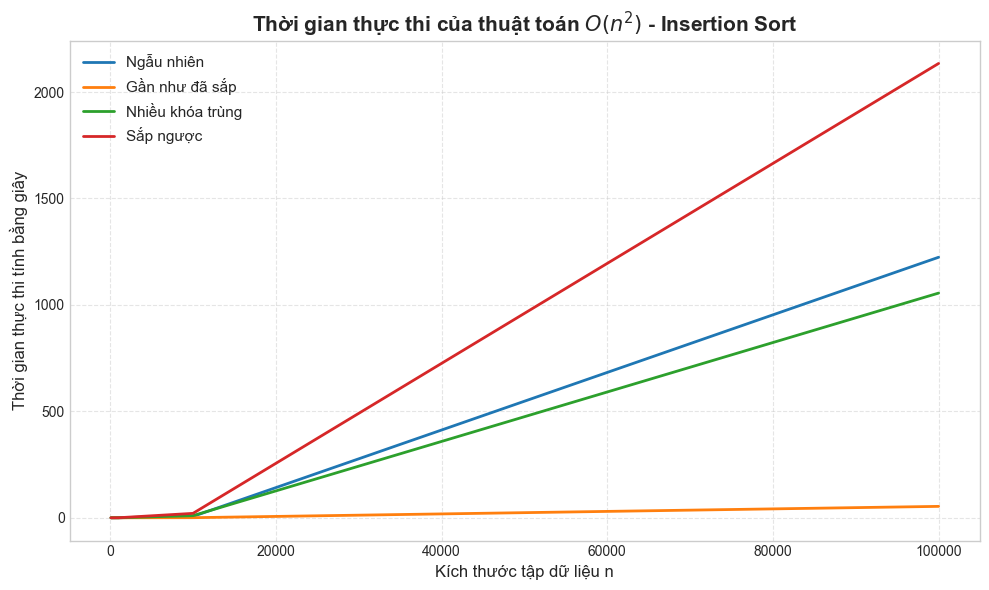

In [21]:
plot_execution_times(
    results_dict=results_radix_sort, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="$O(n)$ - Radix Sort"
)

## 6. Đánh giá 2 thuật toán tuyến tính

### 6.1 Counting Sort

**Ưu điểm**

- Nhanh khi miền giá trị nhỏ hoặc vừa phải; với dữ liệu nhiều khóa trùng, thời gian rất tốt.
- Không cần so sánh từng cặp phần tử, phù hợp cho dữ liệu số nguyên không âm.
- Dễ cài đặt, dễ kiểm soát tính ổn định (nếu triển khai bản stable).

**Nhược điểm**

- Phụ thuộc mạnh vào miền giá trị `k` (giá trị lớn nhất). Độ phức tạp là `O(n + k)`, không thuần `O(n)` trong mọi trường hợp.
- Tốn bộ nhớ `O(k)` cho mảng đếm; khi `k` lớn, bộ nhớ và thời gian khởi tạo tăng đáng kể.
- Không phù hợp cho dữ liệu kiểu tổng quát (không ánh xạ được về miền số nguyên nhỏ).

### 6.2 Radix Sort (LSD, base 10)

**Ưu điểm**

- Không dựa trên so sánh, độ phức tạp `O(d * (n + b))`.
- Khi số chữ số `d` nhỏ và cơ số `b` cố định, thuật toán có xu hướng tuyến tính theo `n`.
- Ít nhạy với thứ tự ban đầu của dữ liệu (ngẫu nhiên, gần sắp, ngược), nên đường thời gian thường khá sát nhau.

**Nhược điểm**

- Có nhiều lượt quét mảng (mỗi chữ số một lượt), nên hằng số thời gian lớn; trong Python thường chậm hơn Counting Sort.
- Cần bộ nhớ phụ `O(n + b)` cho mỗi lượt đếm theo chữ số.
- Chủ yếu phù hợp với khóa dạng số nguyên/chuỗi có cấu trúc theo chữ số.

### 6.3 Có đúng là `O(n)` không?

- Counting Sort: chỉ có thể xem là gần `O(n)` khi `k = O(n)` hoặc `k` đủ nhỏ so với `n`. Trong bộ dữ liệu này, tập `random` có miền giá trị lớn nên chậm hơn rõ rệt; tập `many_duplicates` có miền nhỏ nên nhanh nhất.
- Radix Sort: gần `O(n)` khi `d` và `b` coi như hằng số. Với dữ liệu hiện tại, `b = 10` cố định và `d` nhỏ (khoảng 3-6 chữ số), nên đồ thị tăng gần tuyến tính theo `n`.

**Kết luận ngắn:** Kết quả thực nghiệm phù hợp với lý thuyết: cả hai thuộc nhóm tuyến tính trong điều kiện dữ liệu phù hợp, nhưng không phải lúc nào cũng là `O(n)` thuần túy nếu tham số miền giá trị (`k`, `d`) tăng mạnh.